In [1]:
import pandas as pd
import os
import json
import base64
from PIL import Image
from tqdm import tqdm
import io

In [2]:
model_name = "gpt-4o"
batch_size = 50

In [3]:
PROMPT = """Your task is to extract the main title of the chart image. The main title is typically located at the top of the chart, above the chart area itself, and describes the overall subject of the chart. The title usually describes what data is being presented, the time period, or the geographic location, if applicable. If the chart does not have a discernible main title, your response should be 'Title: None'. Otherwise, your response should be in the format 'Title: <title>'."""

def decode_image(base_64_string):
	image_data = base64.b64decode(base_64_string)
	image = Image.open(io.BytesIO(image_data))
	return image

def encode_image(image_path):
	with open(image_path, "rb") as image:
		return base64.b64encode(image.read()).decode("utf-8")

def format_payload(id, base64_images, prompt):
	
	content = [
		{
			"type": "image_url",
			"image_url": {
				"url": f"data:image/jpeg;base64,{base64_image}",
			}
		} for base64_image in base64_images
	]
	 
	content.append({
		"type": "text",
		"text": prompt
	})
	
	payload = {
		"custom_id": id,
		"method": "POST",
		"url": "/v1/chat/completions",
		"body": {
			"model": model_name,
			"messages": [
				{
					"role": "user",
					"content": content
				}
			],
			"max_tokens": 1000
		}
	}
	 
	return payload

In [56]:
def get_message(dataset, image_path):
	id = f"{dataset}_{image_path.split('/')[-1].split('.')[0]}"
	b64_image = encode_image(image_path)
	payload = format_payload(id, [b64_image], PROMPT)
	
	return payload

counter = 0

datasets = ['t1', 't2', 't3']
paths = ['type1', 'type2', 'type3']
for i in range(len(datasets)):
	chart_names = json.load(open(f"../{datasets[i]}_charts.json"))
	payloads = []
	for chart_name, chart_paths in chart_names.items():
		for path in chart_paths:
			image_path = f"../../../{paths[i]}/simple/{path}"
			payloads.append(get_message(datasets[i], image_path))
			counter += 1
	os.makedirs(f'GPT_batches/{paths[i]}/', exist_ok=True)
	payloads_batched = [payloads[i:i+batch_size] for i in range(0, len(payloads), batch_size)]
	for j, batch in enumerate(payloads_batched):
		for query in batch:
			with open(f'GPT_batches/{paths[i]}/{j}.jsonl', 'a') as f:
				json.dump(query, f)
				f.write('\n')
	  
counter

2649

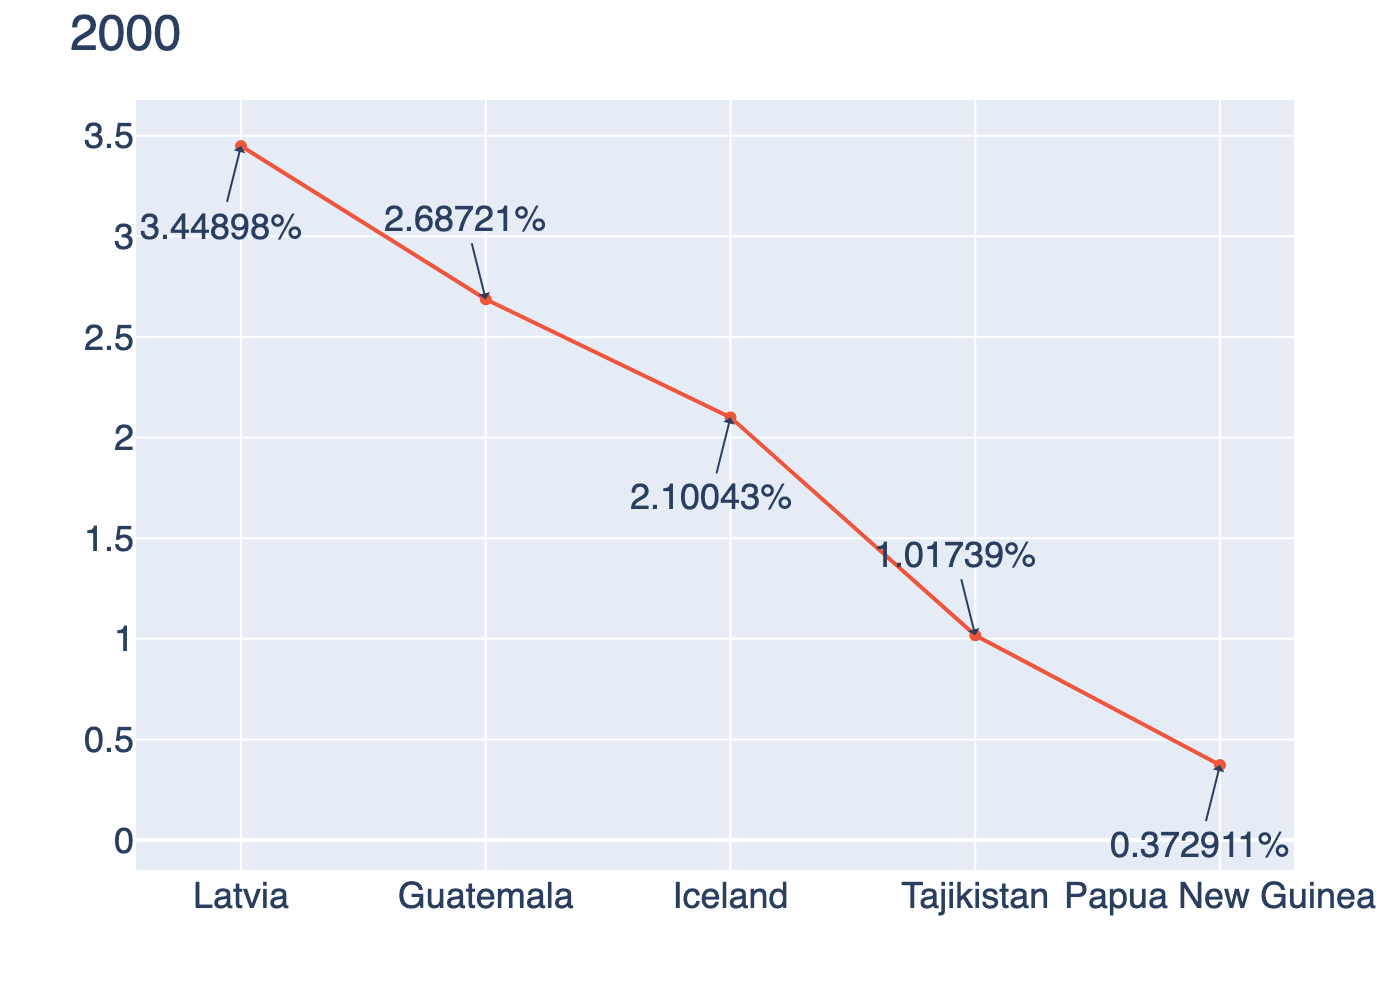

In [40]:
decode_image(payloads[23]['body']['messages'][0]['content'][0]['image_url']['url'].split(',', 1)[1])